<a href="https://colab.research.google.com/github/scadriano/lia1_2026_1/blob/main/Aula%2008%20e%2009%20-%20Projetos%20Alunos/Construindo_um_modelo_com_TensorFlow_Cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='Blue'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow</font>

**Pipeline de um Projeto de IA:**
Dados → Pré-processamento → Modelo → Avaliação

*O valor não está no dataset — está na capacidade de aplicar o mesmo pipeline em diferentes problemas!*

Construir um modelo de Inteligência Artificial capaz de classificar imagens considerando 13 atributos: ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE","DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"].

## Lembrando que o dataset utilizado é o Boston Housing
- ***Os dados são de casas nos subúrbios de Boston no final dos anos 1970, quando os preços imobiliários eram muito mais baixos do que hoje.***

- **É um modelo de regressão**

## Verificando a versão do python instalada

In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


## Instalando o TensorFlow localmente

In [ ]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow

In [ ]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


## Realizando importações necessárias

In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
# Utilizado para parar o modelo durante o treino quando ele para de melhorar
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

## Carregando os dados - matéria prima

In [ ]:
# Carrega o dataset Boston Housing - Já está no Keras!
(dados_treino, precos_treino), (dados_teste, precos_teste) = datasets.boston_housing.load_data()

In [ ]:
# Formato dos dados (qtd. amostra, qtd. colunas)
print("Formato dos dados de treino:", dados_treino.shape)
print("Formato dos dados de teste:", dados_teste.shape)

Formato dos dados de treino: (404, 13)
Formato dos dados de teste: (102, 13)


In [ ]:
# Atributos das features numéricas
nome_atributos = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE","DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

| Coluna  | Descrição                                                                 |
|---------|---------------------------------------------------------------------------|
| CRIM    | Taxa de criminalidade per capita na região                                |
| ZN      | Proporção de terrenos residenciais com lotes maiores que 25.000 pés²     |
| INDUS   | Proporção de acres de negócios não varejistas por cidade (zonas industriais) |
| CHAS    | Variável binária: 1 se o imóvel está próximo ao rio Charles, 0 caso contrário |
| NOX     | Concentração de óxidos nítricos no ar (poluição), em partes por 10 milhões |
| RM      | Número médio de cômodos por habitação                                     |
| AGE     | Proporção de unidades construídas antes de 1940 (idade das casas, %)      |
| DIS     | Distâncias ponderadas a cinco principais centros de emprego de Boston     |
| RAD     | Índice de acessibilidade às rodovias radiais                              |
| TAX     | Taxa de imposto predial por US$ 10.000                                    |
| PTRATIO | Razão aluno-professor nas escolas da cidade                               |
| B       | Fórmula: 1000(Bk - 0.63)², onde Bk é a proporção de negros por cidade     |
| LSTAT   | Percentual da população com status socioeconômico mais baixo              |
| MEDV    | Valor mediano das casas ocupadas pelos proprietários (em milhares de dólares) |

## Pré-processamento e Visualização dos dados

In [ ]:
# Padroniza os atributos para que fiquem na mesma escala
media = dados_treino.mean(axis=0)
desvio_padrao = dados_treino.std(axis=0)

dados_treino = (dados_treino - media) / desvio_padrao
dados_teste = (dados_teste - media) / desvio_padrao

In [ ]:
# Função para visualizar a distribuição dos preços
def visualiza_dados(precos):
    plt.figure(figsize=(8, 5))
    plt.hist(precos, bins=30)
    plt.title("Distribuição dos preços das casas")
    plt.xlabel("Preço mediano (em milhares de dólares)")
    plt.ylabel("Quantidade")
    plt.show()

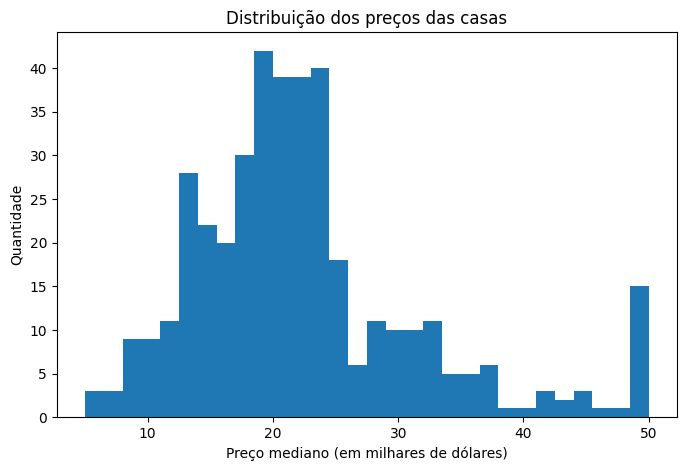

In [ ]:
# Executa a função de visualização
visualiza_dados(precos_treino)

## Análise exploratória dos dados - Correlação

In [ ]:
# DataFrame para análise
df_treino = pd.DataFrame(dados_treino, columns=nome_atributos)
df_treino['PRICE'] = precos_treino

In [ ]:
# Resumo estatístico do preço
df_treino[['PRICE']].describe()

# mean - média
# std - desvio padão
# min - menor preço do dataset(Casa mais barata)
# 1º Quartil
# Mediana
# 3º Quartil
# Max - Maior valor do dataset(Casa mais cara)


,PRICE
count,404.000000
mean,22.395050
std,9.210442
min,5.000000
25%,16.675000
50%,20.750000
75%,24.800000
max,50.000000


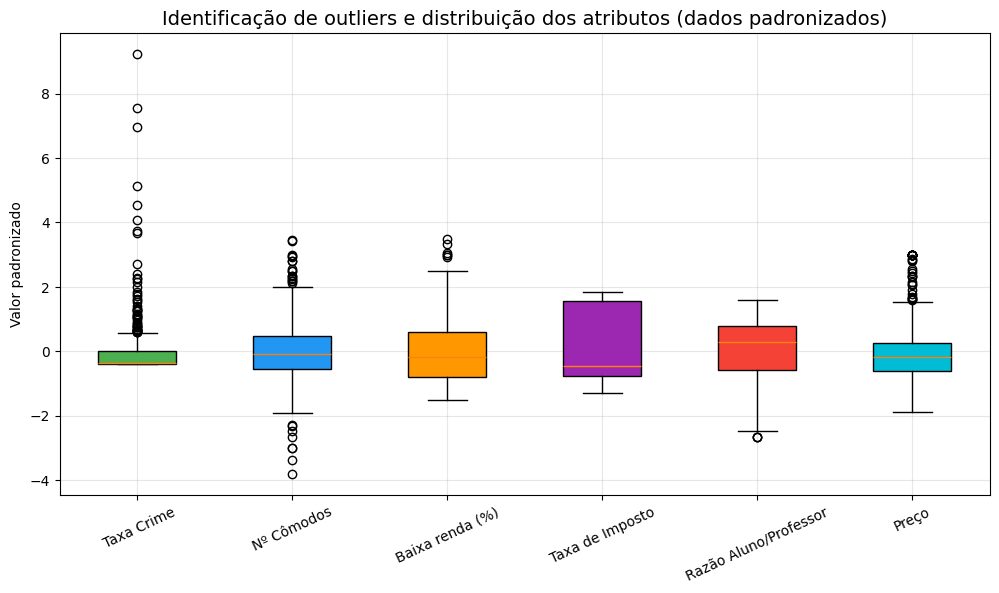

In [ ]:
# Seleciona colunas de interesse e renomeia para nomes mais legíveis
nomes_legiveis = {
    'CRIM': ' Taxa Crime',
    'RM': 'Nº Cômodos',
    'LSTAT': 'Baixa renda (%)',
    'TAX': 'Taxa de Imposto',
    'PTRATIO': 'Razão Aluno/Professor',
    'PRICE': 'Preço'
}

df_plot = df_treino[['CRIM', 'RM', 'LSTAT', 'TAX', 'PTRATIO', 'PRICE']].rename(columns=nomes_legiveis)

# Padronização manual: (x - média) / desvio padrão
df_scaled = (df_plot - df_plot.mean()) / df_plot.std()

# Cria o boxplot
plt.figure(figsize=(12, 6))

box = plt.boxplot(df_scaled.values, patch_artist=True)

cores = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for patch, cor in zip(box['boxes'], cores):
    patch.set_facecolor(cor)

plt.xticks(range(1, len(df_scaled.columns) + 1), df_scaled.columns, rotation=25)
plt.title('Identificação de outliers e distribuição dos atributos (dados padronizados)', fontsize=14)
plt.ylabel('Valor padronizado')
plt.grid(alpha=0.3)
plt.show()

## Construção do Modelo

In [ ]:
# Arquitetura do Modelo -> Regressão com camadas densas

modelo_lia = models.Sequential()

# Camada de entrada
modelo_lia.add(layers.Input(shape=(dados_treino.shape[1],)))

# Camadas ocultas
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dense(64, activation='relu'))

In [ ]:
# Camada de saída
modelo_lia.add(layers.Dense(1))

In [ ]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilação do modelo
modelo_lia.compile(optimizer='adam',
                   loss='mse',
                   metrics=['mae'])

# adam - algoritmo de otimização
# loss - erro quadrático médio
# mae - Erro Absoluto Médio

In [ ]:
%%time
# Para o treinamento automaticamente quando o modelo para de melhorar
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = modelo_lia.fit(
    dados_treino,
    precos_treino,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - loss: 553.5364 - mae: 21.5741 - val_loss: 581.3820 - val_mae: 22.1844
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 468.7863 - mae: 19.4487 - val_loss: 474.7804 - val_mae: 19.6470
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 342.7288 - mae: 16.1425 - val_loss: 312.7865 - val_mae: 15.3119
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 184.6397 - mae: 11.0266 - val_loss: 147.9702 - val_mae: 9.2814
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 78.5704 - mae: 6.5586 - val_loss: 83.0838 - val_mae: 6.8223
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50.9139 - mae: 5.1908 - val_loss: 56.6041 - val_mae: 5.5725
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 36.4295 - mae: 4.1933 - val_loss: 40.0956 - val_mae: 4.5108
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28.9511 - mae: 3.6603 - val_loss: 31.8848 - val_mae: 4.0323
Epoch 9/200
21/21 ━━━━━━━━━━━━━

## Avaliação do modelo de regressão

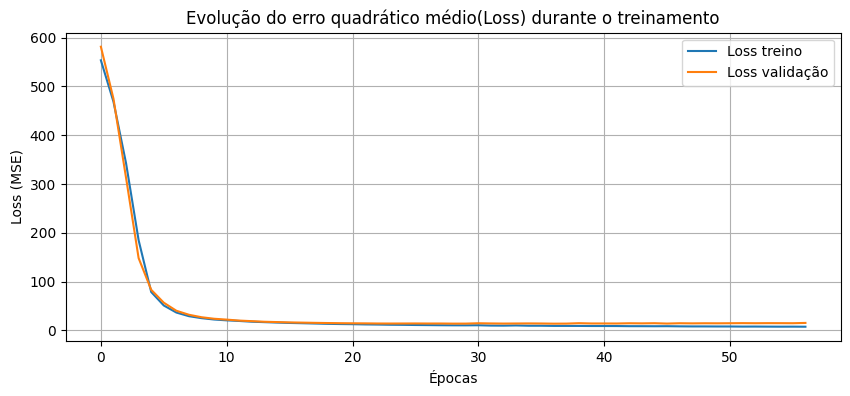

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Loss treino')
plt.plot(history.history['val_loss'], label='Loss validação')
plt.title('Evolução do erro quadrático médio(Loss) durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

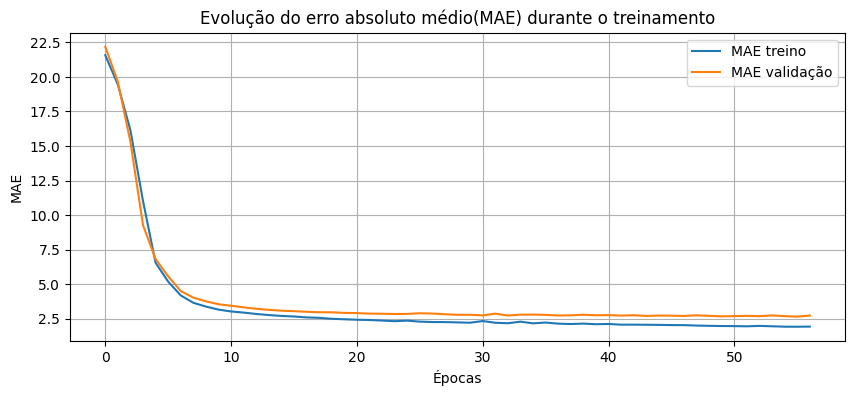

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='MAE treino')
plt.plot(history.history['val_mae'], label='MAE validação')
plt.title('Evolução do erro absoluto médio(MAE) durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Avalia o modelo
erro_teste, mae_teste = modelo_lia.evaluate(dados_teste, precos_teste, verbose=2)

4/4 - 1s - 134ms/step - loss: 24.2807 - mae: 3.2212


In [ ]:
print('\nMAE com dados de teste:', mae_teste)


MAE com dados de teste: 3.22123384475708


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


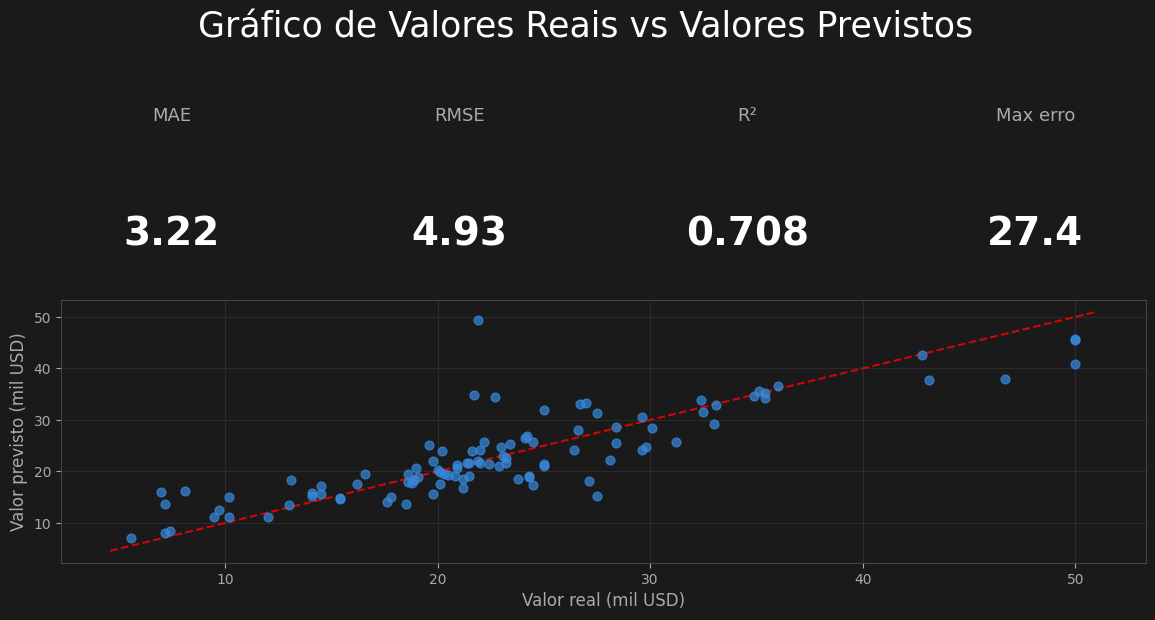

In [ ]:
# Visualiza a relação entre valores reais e previstos
previsoes_teste = modelo_lia.predict(dados_teste).flatten()
residuos = precos_teste - previsoes_teste

mae      = np.mean(np.abs(residuos))
rmse     = np.sqrt(np.mean(residuos**2))
ss_res   = np.sum(residuos**2)
ss_tot   = np.sum((precos_teste - np.mean(precos_teste))**2)
r2       = 1 - (ss_res / ss_tot)
max_erro = np.max(np.abs(residuos))

fig = plt.figure(figsize=(14, 7), facecolor='#1a1a1a')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.05, wspace=0.3)

for i, (label, val, fmt) in enumerate([
    ('MAE',      mae,      '{:.2f}'),
    ('RMSE',     rmse,     '{:.2f}'),
    ('R²',       r2,       '{:.3f}'),
    ('Max erro', max_erro, '{:.1f}'),
]):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#1a1a1a')
    ax.axis('off')
    ax.text(0.5, 0.65, label, ha='center', va='center',
            color='#aaaaaa', fontsize=13, transform=ax.transAxes)
    ax.text(0.5, 0.2, fmt.format(val), ha='center', va='center',
            color='white', fontsize=28, fontweight='bold', transform=ax.transAxes)

ax_main = fig.add_subplot(gs[1, :])
ax_main.set_facecolor('#1a1a1a')
ax_main.tick_params(colors='#aaaaaa')
for spine in ax_main.spines.values():
    spine.set_edgecolor('#444444')
ax_main.grid(color='#333333', linewidth=0.5)

ax_main.scatter(precos_teste, previsoes_teste, alpha=0.7, color='#378ADD', s=40, zorder=3)

lim_min = min(precos_teste.min(), previsoes_teste.min()) - 1
lim_max = max(precos_teste.max(), previsoes_teste.max()) + 1
ax_main.plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', linewidth=1.5, alpha=0.8, zorder=2)

ax_main.set_xlabel('Valor real (mil USD)',     color='#aaaaaa', fontsize=12)
ax_main.set_ylabel('Valor previsto (mil USD)', color='#aaaaaa', fontsize=12)
fig.suptitle('Gráfico de Valores Reais vs Valores Previstos',
              color='white', fontsize=25, y=0.9)

plt.savefig('resultado_modelo.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

# MAE: erro médio absoluto (≈ 3.16 mil dólares). Quanto menor, melhor.
# RMSE: erro médio que penaliza erros grandes (≈ 5.00), indica presença de outliers.
# R²: nível de explicação do modelo (≈ 0.70 → explica 70% dos dados).
# Max erro: maior erro individual (≈ 31.1), indica casos extremos.

## Previsão com novos dados

In [ ]:
# Novo exemplo para previsão
# O reshape(1, -1) garante que o dado tem o formato (1, 13) que o modelo espera..
novo_dado = dados_teste[0].reshape(1, -1)

In [ ]:
# Dimensões da amostra
novo_dado.shape

(1, 13)

In [ ]:
# Não é necessário novo pré-processamento, pois a amostra já veio padronizada do conjunto de teste
novo_dado_array = novo_dado

In [ ]:
# Essa linha garante que o dado está no formato (1, 13) que o modelo espera receber.
novo_dado_array = np.expand_dims(novo_dado_array[0], axis=0)
# Mostra o formato do dado
novo_dado_array.shape

(1, 13)

In [ ]:
"""## Previsão com novos dados informados pelo usuário"""

# Lista com nome interno, explicação simples e orientação de preenchimento
atributos_info = [
    ("CRIM", "Taxa de criminalidade da região", "Digite um número, por exemplo: 0.1"),
    ("ZN", "Porcentagem de áreas residenciais com terrenos grandes", "Digite um valor de 0 a 100"),
    ("INDUS", "Porcentagem de áreas industriais na região", "Digite um valor de 0 a 100"),
    ("CHAS", "O imóvel fica perto do rio?", "Digite 1 para sim ou 0 para não"),
    ("NOX", "Nível de poluição do ar", "Digite um número, por exemplo: 0.5"),
    ("RM", "Número médio de cômodos da casa", "Digite um número, por exemplo: 6"),
    ("AGE", "Porcentagem de casas antigas na região", "Digite um valor de 0 a 100"),
    ("DIS", "Distância até centros de emprego", "Digite um número, por exemplo: 4"),
    ("RAD", "Facilidade de acesso a rodovias", "Digite um número inteiro, por exemplo: 5"),
    ("TAX", "Valor do imposto da região", "Digite um número, por exemplo: 300"),
    ("PTRATIO", "Quantidade de alunos por professor", "Digite um número, por exemplo: 15"),
    ("B", "Índice estatístico da composição demográfica da região", "Digite um número, por exemplo: 390"),
    ("LSTAT", "Porcentagem da população de baixa renda", "Digite um valor de 0 a 100")
]

print("\nPreencha as informações da casa ou da região para estimar o preço.\n")
print("Atenção: informe os valores em formato numérico usando ponto se necessário.\n")

valores_usuario = []

for nome, descricao, orientacao in atributos_info:
    while True:
        try:
            print(f"{nome} - {descricao}")
            valor = float(input(f"{orientacao}: "))
            valores_usuario.append(valor)
            print()
            break
        except ValueError:
            print("Valor inválido. Digite apenas números.\n")

# Converte para array NumPy
novo_dado_bruto = np.array(valores_usuario, dtype=float)

# Mostra um resumo do que foi digitado
print("\nResumo dos dados informados:")
for i, (nome, descricao, orientacao) in enumerate(atributos_info):
    print(f"{nome} - {descricao}: {novo_dado_bruto[i]}")

# Padroniza os dados com a mesma média e desvio usados no treinamento
novo_dado_padronizado = (novo_dado_bruto - media) / desvio_padrao
novo_dado_padronizado = novo_dado_padronizado.reshape(1, -1)

# Faz a previsão
previsao = modelo_lia.predict(novo_dado_padronizado)
preco_previsto = previsao[0][0]

print(f"\nPreço previsto para a casa/região: {preco_previsto:.2f} mil dólares")


Preencha as informações da casa ou da região para estimar o preço.

Atenção: informe os valores em formato numérico usando ponto se necessário.

CRIM - Taxa de criminalidade da região
Digite um número, por exemplo: 0.1: 0.8

ZN - Porcentagem de áreas residenciais com terrenos grandes
Digite um valor de 0 a 100: 10

INDUS - Porcentagem de áreas industriais na região
Digite um valor de 0 a 100: 40

CHAS - O imóvel fica perto do rio?
Digite 1 para sim ou 0 para não: 0

NOX - Nível de poluição do ar
Digite um número, por exemplo: 0.5: 0.8

RM - Número médio de cômodos da casa
Digite um número, por exemplo: 6: 2

AGE - Porcentagem de casas antigas na região
Digite um valor de 0 a 100: 10

DIS - Distância até centros de emprego
Digite um número, por exemplo: 4: 6

RAD - Facilidade de acesso a rodovias
Digite um número inteiro, por exemplo: 5: 3

TAX - Valor do imposto da região
Digite um número, por exemplo: 300: 500

PTRATIO - Quantidade de alunos por professor
Digite um número, por exempl

In [ ]:
"""## Teste do modelo com cenários definidos"""

import pandas as pd
import numpy as np

# Definição dos cenários
casos = {
    "Casa média": [0.1,20,5,0,0.5,6,60,4,2,300,16,390,12],
    "Casa de alto padrão": [0.01,80,2,1,0.4,7.5,20,6,1,250,13,395,5],
    "Região mais simples": [0.8,0,15,0,0.7,5,90,2,5,400,20,350,25]
}

# Criar DataFrame
df_casos = pd.DataFrame(casos).T
df_casos.columns = nome_atributos

print("📊 Dados de entrada:")
display(df_casos)

# Padronizar (mesma média e desvio do treino)
dados_padronizados = (df_casos.values - media) / desvio_padrao

# Fazer previsões
previsoes = modelo_lia.predict(dados_padronizados).flatten()

# Adicionar resultado
df_casos['Preço previsto (mil USD)'] = previsoes

print("\n💰 Resultados das previsões:")
display(df_casos)

📊 Dados de entrada:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
Casa média,0.10,20.0,5.0,0.0,0.5,6.0,60.0,4.0,2.0,300.0,16.0,390.0,12.0
Casa de alto padrão,0.01,80.0,2.0,1.0,0.4,7.5,20.0,6.0,1.0,250.0,13.0,395.0,5.0
Região mais simples,0.80,0.0,15.0,0.0,0.7,5.0,90.0,2.0,5.0,400.0,20.0,350.0,25.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step

💰 Resultados das previsões:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Preço previsto (mil USD)
Casa média,0.10,20.0,5.0,0.0,0.5,6.0,60.0,4.0,2.0,300.0,16.0,390.0,12.0,20.460825
Casa de alto padrão,0.01,80.0,2.0,1.0,0.4,7.5,20.0,6.0,1.0,250.0,13.0,395.0,5.0,44.488041
Região mais simples,0.80,0.0,15.0,0.0,0.7,5.0,90.0,2.0,5.0,400.0,20.0,350.0,25.0,15.345236
